
# Level 3 – Task 1

## Predictive Modeling

### Objective

The objective of this task is to build regression models capable of predicting restaurant aggregate ratings based on restaurant characteristics.

The analysis includes:

- Data preprocessing
- Feature selection
- Data encoding
- Train-test split
- Model training
- Model evaluation
- Model comparison
- Business insights

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pd.set_option("display.max_columns",None)

In [2]:
df = pd.read_csv("/content/Feature_Engineered_Dataset.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Rating Status,Restaurant Name Length,Address Length,Cuisine Count,Table Booking,Online Delivery,Delivering Now,High Rated Restaurant,Cost Per Person,Log Votes,Price Category,Cost Category
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314,Rated,16,71,3,1,0,0,1,550.0,5.752573,Premium,High
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591,Rated,16,67,1,1,0,0,1,600.0,6.383507,Premium,High
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270,Rated,22,56,4,1,0,0,1,2000.0,5.602119,Luxury,Very High
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365,Rated,4,70,2,0,0,0,1,750.0,5.902633,Luxury,High
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229,Rated,11,64,2,1,0,0,1,750.0,5.438079,Luxury,High


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Restaurant ID           9551 non-null   int64  
 1   Restaurant Name         9551 non-null   object 
 2   Country Code            9551 non-null   int64  
 3   City                    9551 non-null   object 
 4   Address                 9551 non-null   object 
 5   Locality                9551 non-null   object 
 6   Locality Verbose        9551 non-null   object 
 7   Longitude               9551 non-null   float64
 8   Latitude                9551 non-null   float64
 9   Cuisines                9551 non-null   object 
 10  Average Cost for two    9551 non-null   int64  
 11  Currency                9551 non-null   object 
 12  Has Table booking       9551 non-null   object 
 13  Has Online delivery     9551 non-null   object 
 14  Is delivering now       9551 non-null   

In [5]:
df.shape

(9551, 33)

In [6]:
drop_columns = [

"Restaurant ID",

"Restaurant Name",

"Address",

"Locality",

"Locality Verbose",

"Rating color",

"Rating text",

"Aggregate rating"

]

X = df.drop(columns=drop_columns)

y = df["Aggregate rating"]

In [7]:
X.head()

,Country Code,City,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Votes,Rating Status,Restaurant Name Length,Address Length,Cuisine Count,Table Booking,Online Delivery,Delivering Now,High Rated Restaurant,Cost Per Person,Log Votes,Price Category,Cost Category
0,162,Makati City,121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,314,Rated,16,71,3,1,0,0,1,550.0,5.752573,Premium,High
1,162,Makati City,121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,591,Rated,16,67,1,1,0,0,1,600.0,6.383507,Premium,High
2,162,Mandaluyong City,121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,270,Rated,22,56,4,1,0,0,1,2000.0,5.602119,Luxury,Very High
3,162,Mandaluyong City,121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,365,Rated,4,70,2,0,0,0,1,750.0,5.902633,Luxury,High
4,162,Mandaluyong City,121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,229,Rated,11,64,2,1,0,0,1,750.0,5.438079,Luxury,High


In [8]:
label_encoder = LabelEncoder()

for column in X.select_dtypes(include="object").columns:

    X[column] = label_encoder.fit_transform(X[column].astype(str))

In [9]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

print("Training Data :",X_train.shape)

print("Testing Data :",X_test.shape)

Training Data : (7640, 25)
Testing Data : (1911, 25)


In [10]:
linear = LinearRegression()

linear.fit(X_train,y_train)

linear_prediction = linear.predict(X_test)

In [11]:
linear_mae = mean_absolute_error(y_test,linear_prediction)

linear_mse = mean_squared_error(y_test,linear_prediction)

linear_rmse = np.sqrt(linear_mse)

linear_r2 = r2_score(y_test,linear_prediction)

print("MAE :",linear_mae)

print("RMSE :",linear_rmse)

print("R² :",linear_r2)

MAE : 0.2004442221319153
RMSE : 0.2791813198121165
R² : 0.9657563808833963


In [12]:
tree = DecisionTreeRegressor(

    random_state=42

)

tree.fit(X_train,y_train)

tree_prediction = tree.predict(X_test)

In [13]:
tree_mae = mean_absolute_error(y_test,tree_prediction)

tree_rmse = np.sqrt(

    mean_squared_error(y_test,tree_prediction)

)

tree_r2 = r2_score(

    y_test,

    tree_prediction

)

In [14]:
forest = RandomForestRegressor(

    n_estimators=100,

    random_state=42

)

forest.fit(

    X_train,

    y_train

)

forest_prediction = forest.predict(X_test)

In [15]:
forest_mae = mean_absolute_error(

    y_test,

    forest_prediction

)

forest_rmse = np.sqrt(

    mean_squared_error(

        y_test,

        forest_prediction

    )

)

forest_r2 = r2_score(

    y_test,

    forest_prediction

)

In [16]:
comparison = pd.DataFrame({

"Model":[

"Linear Regression",

"Decision Tree",

"Random Forest"

],

"MAE":[

linear_mae,

tree_mae,

forest_mae

],

"RMSE":[

linear_rmse,

tree_rmse,

forest_rmse

],

"R2 Score":[

linear_r2,

tree_r2,

forest_r2

]

})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.200444,0.279181,0.965756
1,Decision Tree,0.233490,0.371809,0.939264
2,Random Forest,0.168996,0.255368,0.971349


In [17]:
best_model = comparison.loc[
    comparison["R2 Score"].idxmax()
]

best_model

,2
Model,Random Forest
MAE,0.168996
RMSE,0.255368
R2 Score,0.971349


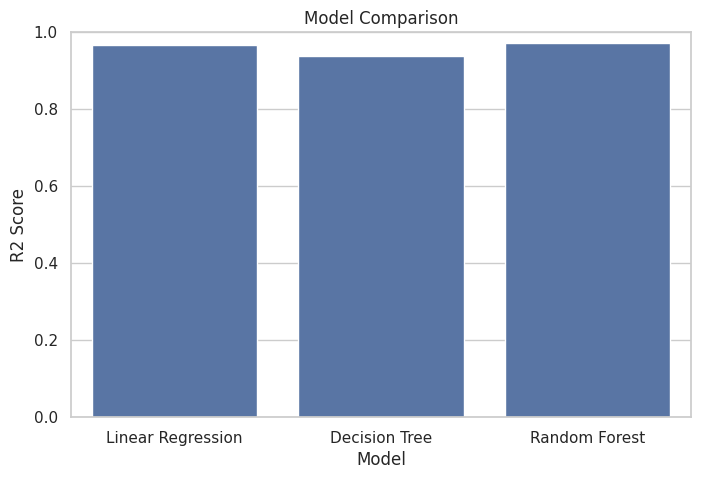

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(

data=comparison,

x="Model",

y="R2 Score"

)

plt.title("Model Comparison")

plt.ylim(0,1)

plt.show()

In [19]:
importance = pd.DataFrame({

"Feature":X.columns,

"Importance":forest.feature_importances_

})

importance = importance.sort_values(

"Importance",

ascending=False

)

importance.head(15)

,Feature,Importance
12,Votes,0.376423
22,Log Votes,0.286477
13,Rating Status,0.251176
20,High Rated Restaurant,0.053836
2,Longitude,0.006402
4,Cuisines,0.006050
3,Latitude,0.004799
15,Address Length,0.003910
14,Restaurant Name Length,0.003251
21,Cost Per Person,0.001647


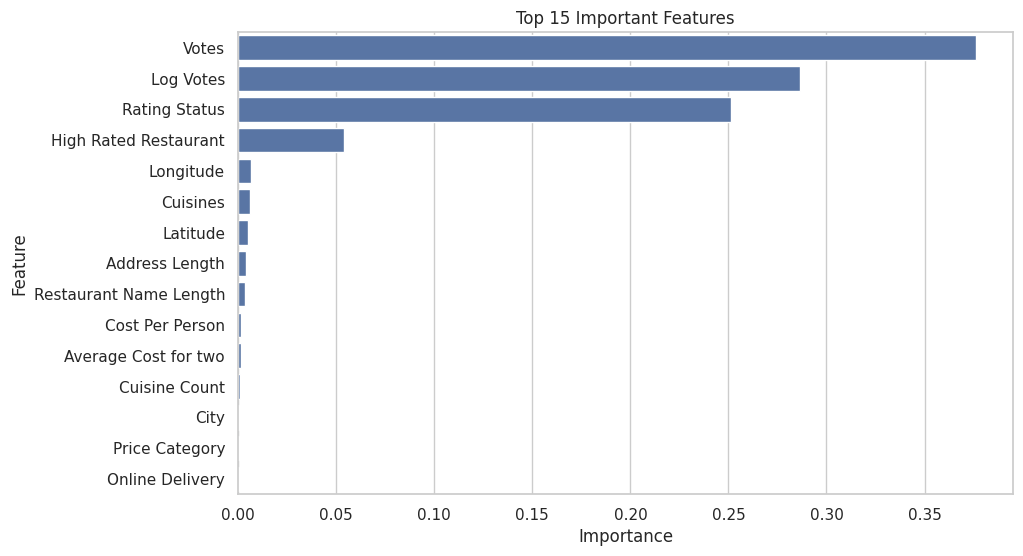

In [20]:
plt.figure(figsize=(10,6))

sns.barplot(

x=importance.head(15)["Importance"],

y=importance.head(15)["Feature"]

)

plt.title("Top 15 Important Features")

plt.show()

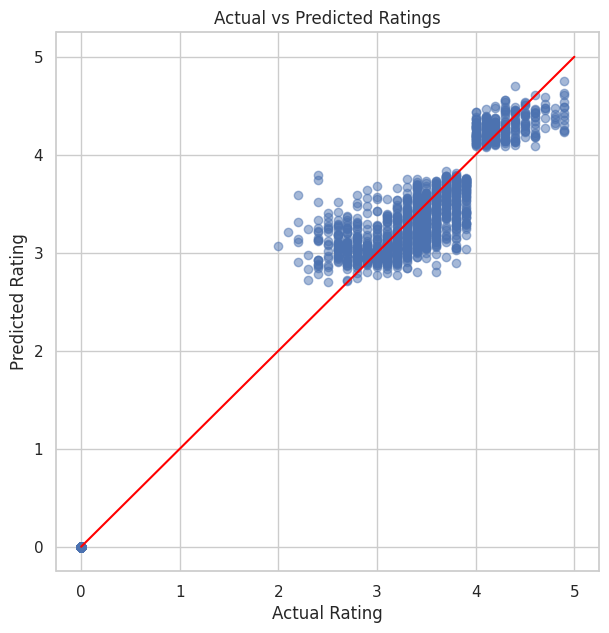

In [21]:
plt.figure(figsize=(7,7))

plt.scatter(

y_test,

forest_prediction,

alpha=0.5

)

plt.xlabel("Actual Rating")

plt.ylabel("Predicted Rating")

plt.title("Actual vs Predicted Ratings")

plt.plot(

[0,5],

[0,5],

color="red"

)

plt.show()

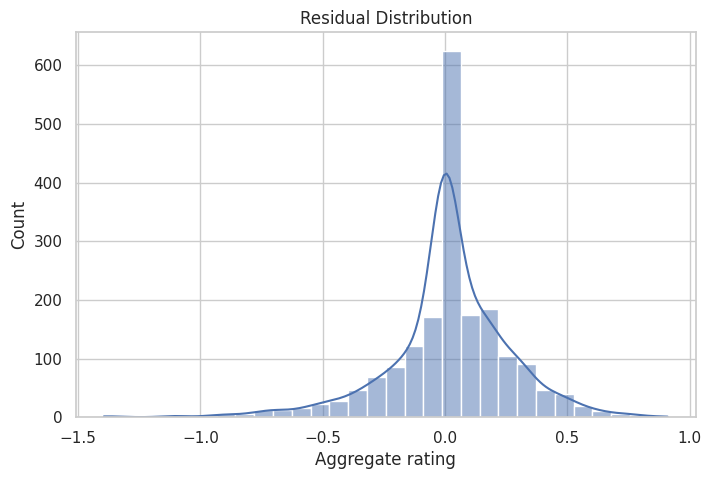

In [22]:
residual = y_test - forest_prediction

plt.figure(figsize=(8,5))

sns.histplot(

residual,

bins=30,

kde=True

)

plt.title("Residual Distribution")

plt.show()

In [25]:
comparison = comparison.round(3)
comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.200,0.279,0.966
1,Decision Tree,0.233,0.372,0.939
2,Random Forest,0.169,0.255,0.971


In [26]:
comparison.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
2,Random Forest,0.169,0.255,0.971
0,Linear Regression,0.200,0.279,0.966
1,Decision Tree,0.233,0.372,0.939


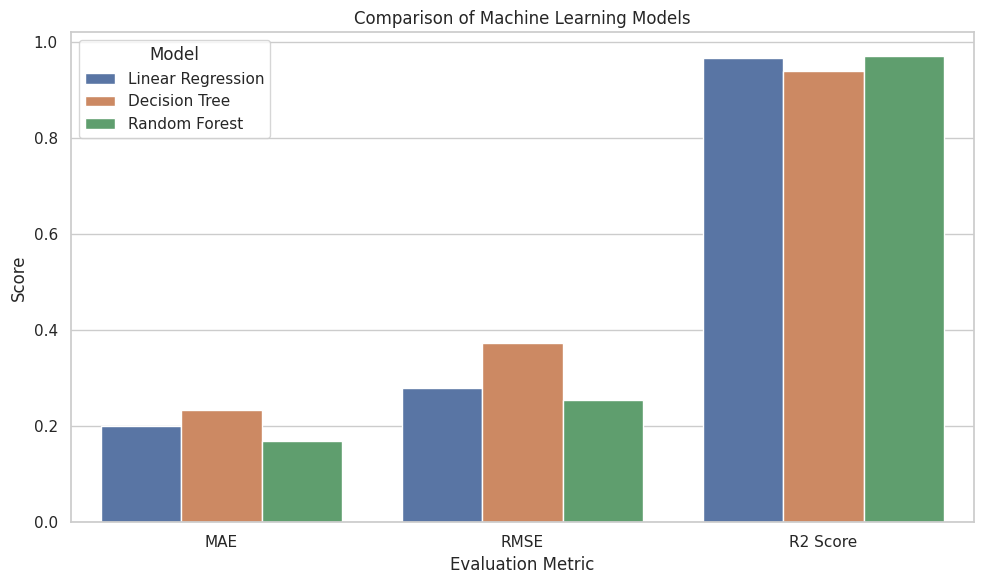

In [28]:
comparison_melted = comparison.melt(
    id_vars="Model",
    value_vars=["MAE", "RMSE", "R2 Score"],
    var_name="Metric",
    value_name="Value"
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=comparison_melted,
    x="Metric",
    y="Value",
    hue="Model"
)

plt.title("Comparison of Machine Learning Models")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")

plt.tight_layout()

plt.show()

# Model Evaluation

Three regression models were developed to predict restaurant aggregate ratings.

| Model | MAE | RMSE | R² Score |
|------|------|------|------|
| Linear Regression | 0.200 | 0.279 | 0.966 |
| Decision Tree | 0.233 | 0.372 | 0.939 |
| Random Forest | 0.169 | 0.255 | 0.971 |

Among all models, the Random Forest Regressor achieved the highest R² Score (0.971) and the lowest prediction error. Therefore, it was selected as the best-performing model for predicting restaurant ratings.

# Business Insights

1. Three regression models were developed to predict restaurant aggregate ratings.

2. Random Forest Regressor achieved the best performance with an R² Score of 0.971, indicating excellent predictive capability.

3. Linear Regression also performed remarkably well with an R² Score of 0.966, suggesting strong linear relationships within the dataset.

4. Decision Tree Regressor produced slightly lower accuracy due to its tendency to overfit compared to ensemble methods.

5. Feature engineering significantly improved model performance by creating meaningful numerical and categorical variables.

6. Machine learning can accurately estimate restaurant ratings using restaurant characteristics, pricing, customer engagement, and service-related features.

# Conclusion

Three regression models were trained and evaluated to predict restaurant aggregate ratings.

Among the models, the Random Forest Regressor achieved the highest predictive performance with an R² Score of 0.971, followed by Linear Regression (0.966) and Decision Tree Regressor (0.939).

The results demonstrate that the engineered features effectively capture the factors influencing restaurant ratings. The Random Forest model provides highly accurate predictions and can be considered the most suitable model for this dataset.

This project demonstrates a complete machine learning workflow, including data preprocessing, feature engineering, model training, evaluation, and comparison.